### Importing Libraries

In [30]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

GPU Usage?

In [31]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using the GPU!")

    gpus = tf.config.list_physical_devices('GPU')
    print("Available GPUs:", gpus)

    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU Details:", details)
else:
    print("TensorFlow is using the CPU.")

TensorFlow is using the GPU!
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Details: {'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU', 'compute_capability': (8, 6)}


In [32]:
import os
from tensorflow.keras.models import load_model

MODEL_PATH_1 = r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\H5\E27_CLAHE_Contrast_Xception_P4I3A3M7T4.keras"
MODEL_PATH_2 = r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\H5\E23_CLAHE_Contrast_Xception_P4I3A2M7T4.keras"   
MODEL_PATH_3 = r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\H5\E5_ImprovedCNN_P1I1A3M2T2.h5"

print("Model 1 exists:", os.path.exists(MODEL_PATH_1))
print("Model 2 exists:", os.path.exists(MODEL_PATH_2))
print("Model 3 exists:", os.path.exists(MODEL_PATH_3))

Model 1 exists: True
Model 2 exists: True
Model 3 exists: True


In [33]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Pneumonia Data___Set


In [34]:
labels = ['PNEUMONIA', 'NORMAL']
img_resize = 224

def get_data(dir):
    data = []
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for label in labels:
        path = os.path.join(dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                if img.lower().endswith(('.jpeg', '.jpg', '.png')):
                    img_path = os.path.join(path, img)

                    img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                    if img_arr is None:
                        continue

                    resized_arr = cv2.resize(img_arr, (img_resize, img_resize))

                    clahe_img = clahe.apply(resized_arr)
                    contrast_img = cv2.convertScaleAbs(clahe_img, alpha=1.2, beta=0)

                    rgb_arr = cv2.cvtColor(contrast_img, cv2.COLOR_GRAY2RGB)

                    data.append([rgb_arr, class_num])

            except Exception as e:
                print(f"Error loading image {img}: {e}")

    return np.array(data, dtype='object')

In [35]:
train = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\train")
val   = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\val")
test  = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\test")

In [36]:
def count_images(dataset, name):

    pneumonia = 0
    normal = 0

    for i in dataset:
        if i[1] == 0:
            pneumonia += 1
        else:
            normal += 1

    total = pneumonia + normal

    print(f"\n{name} DATASET:")
    print("Total images:", total)
    print("PNEUMONIA images:", pneumonia)
    print("NORMAL images:", normal)


count_images(train, "TRAIN")
count_images(val, "VALIDATION")
count_images(test, "TEST")


TRAIN DATASET:
Total images: 5170
PNEUMONIA images: 3852
NORMAL images: 1318

VALIDATION DATASET:
Total images: 62
PNEUMONIA images: 31
NORMAL images: 31

TEST DATASET:
Total images: 624
PNEUMONIA images: 390
NORMAL images: 234


## Data Visualization && Preprocessing

<Axes: xlabel='count'>

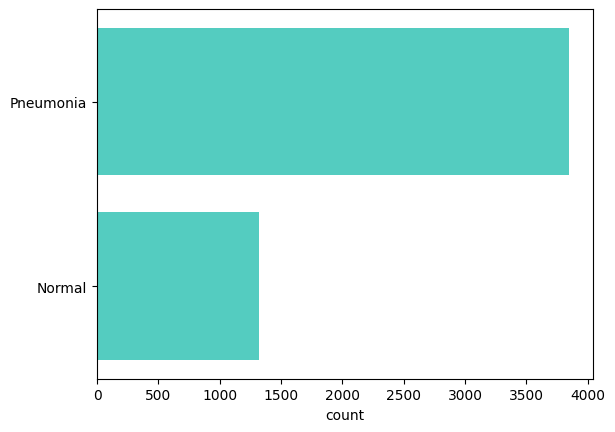

In [37]:
l = []
for i in train:
    if (i[1] == 0):
        l.append('Pneumonia')
    else:
        l.append('Normal')

sns.countplot(y=l, color='#40E0D0')

Text(0.5, 1.0, 'NORMAL')

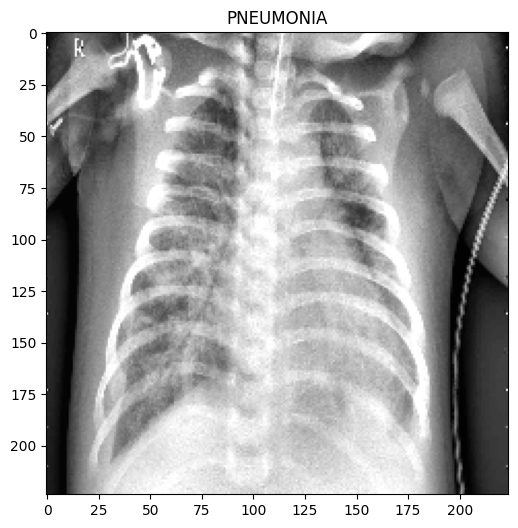

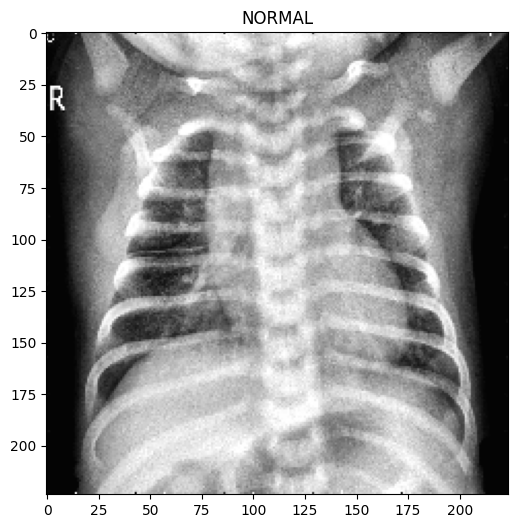

In [38]:
plt.figure(figsize=(6,6))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))
plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [39]:
x_train = []
y_train = []
for feat, label in train:
    x_train.append(feat)
    y_train.append(label)


x_val = []
y_val = []
for feat,label in val:
    x_val.append(feat)
    y_val.append(label)


x_test = []
y_test = []
for feat, label in test:
    x_test.append(feat)
    y_test.append(label)


In [40]:
# print(type(x_train))
# print(type(x_train[0]))
# print("First train image shape:", np.array(x_train[0]).shape)
# print("First val image shape:", np.array(x_val[0]).shape)
# print("First test image shape:", np.array(x_test[0]).shape)

## Normalizing       data ........

In [41]:
#Normalizing.... data
# for reducing computation....
x_train = np.array(x_train, dtype='float32') / 255.0
x_val   = np.array(x_val, dtype='float32') / 255.0
x_test  = np.array(x_test, dtype='float32') / 255.0

# suitable for CNN

In [42]:
x_train = np.array(x_train)
y_train = np.array(y_train)

x_val = np.array(x_val)
y_val = np.array(y_val)

x_test = np.array(x_test)
y_test = np.array(y_test)

print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

x_train shape: (5170, 224, 224, 3)
x_val shape: (62, 224, 224, 3)
x_test shape: (624, 224, 224, 3)


# data augmentation

In [43]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# data__gen = ImageDataGenerator(
#     rotation_range=15,
#     width_shift_range=0.10,
#     height_shift_range=0.10,
#     zoom_range=0.10,
#     horizontal_flip=True
# )

# data__gen.fit(x_train)


# E30 is an ensemble notebook

## Train........

In [44]:
# Load best 3 trained models
model1 = load_model(MODEL_PATH_1, compile=False)   # E25 DenseNet121
model2 = load_model(MODEL_PATH_2, compile=False)   # E24 EfficientNetB0
model3 = load_model(MODEL_PATH_3, compile=False)   # E26 ResNet50

print("All ensemble models loaded successfully")

All ensemble models loaded successfully


In [47]:
pred1 = model1.predict(x_test, batch_size=2, verbose=1)
pred2 = model2.predict(x_test, batch_size=2, verbose=1)
pred3 = model3.predict(x_test, batch_size=2, verbose=1)

print("Prediction shapes:")
print("Model 1:", pred1.shape)
print("Model 2:", pred2.shape)
print("Model 3:", pred3.shape)

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [ ]:
# Soft voting
ensemble_prob = (pred1 + pred2 + pred3) / 3.0

print("Ensemble probability shape:", ensemble_prob.shape)
print("First 10 ensemble probabilities:\n", ensemble_prob[:10])

Ensemble probability shape: (624, 1)
First 10 ensemble probabilities:
 [[3.5583436e-02]
 [8.5995369e-02]
 [6.5748305e-03]
 [1.0575125e-04]
 [2.2033060e-03]
 [2.1638126e-04]
 [8.2847761e-04]
 [7.5672772e-03]
 [1.3099518e-01]
 [3.4408588e-02]]


In [ ]:
# Convert probability to class label
ensemble_pred = (ensemble_prob > 0.5).astype("int32").reshape(-1)

print("First 20 final ensemble predictions:")
print(ensemble_pred[:20])

First 20 final ensemble predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
print("Ensemble Accuracy:", ensemble_accuracy)

Ensemble Accuracy: 0.8685897435897436


In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, ensemble_pred, target_names=['PNEUMONIA', 'NORMAL']))

Classification Report:

              precision    recall  f1-score   support

   PNEUMONIA       0.83      0.99      0.90       390
      NORMAL       0.98      0.66      0.79       234

    accuracy                           0.87       624
   macro avg       0.91      0.83      0.85       624
weighted avg       0.89      0.87      0.86       624



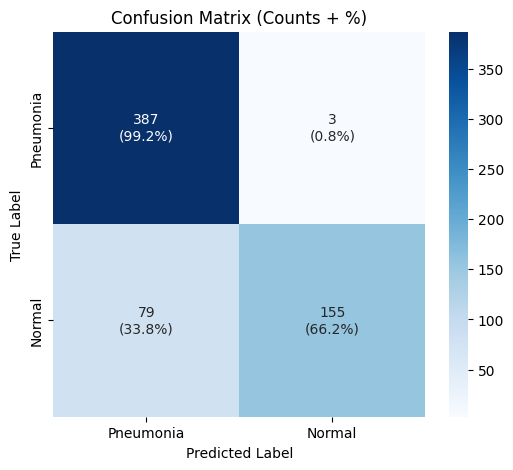

In [ ]:
correct = np.nonzero(ensemble_pred == y_test)[0]
incorrect = np.nonzero(ensemble_pred != y_test)[0]

cm = confusion_matrix(y_test, ensemble_pred)  


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix



# Label
labels = ['Pneumonia', 'Normal']

#percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"


# Plottin confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Counts + %)")
plt.show()

In [ ]:
# save ensemble probabilities and predictions
ensemble_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": ensemble_pred,
    "Probability": ensemble_prob.reshape(-1)
})

print(ensemble_results.head())

   Actual  Predicted  Probability
0       0          0     0.035583
1       0          0     0.085995
2       0          0     0.006575
3       0          0     0.000106
4       0          0     0.002203


In [ ]:
print("Final Ensemble Test Accuracy:", ensemble_accuracy)

Final Ensemble Test Accuracy: 0.8685897435897436


In [ ]:
print(f"Total test samples: {len(y_test)}")
print(f"Correct predictions: {(ensemble_pred == y_test).sum()}")
print(f"Wrong predictions: {(ensemble_pred != y_test).sum()}")

Total test samples: 624
Correct predictions: 542
Wrong predictions: 82


In [ ]:
ensemble_pred[:15]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
# predictions = (model.predict(x_test) > 0.5).astype('int32')
# predictions = predictions.reshape(1,-1)[0]
# predictions[:15]

In [ ]:
print(classification_report(y_test, ensemble_pred, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.83      0.99      0.90       390
   Normal (Class 1)       0.98      0.66      0.79       234

           accuracy                           0.87       624
          macro avg       0.91      0.83      0.85       624
       weighted avg       0.89      0.87      0.86       624



In [ ]:


# cm = confusion_matrix(y_test,predictions)

In [ ]:
# correct = np.nonzero(predictions == y_test)[0]
# incorrect = np.nonzero(predictions != y_test)[0]

In [ ]:
# sns.heatmap(cm, annot=True)

#Some correctly Predicted Classes---->>>

In [ ]:
# i = 0
# plt.figure(figsize=(6,15))
# for c in correct[10:18]:
#     plt.subplot(4,2,i+1)
#     plt.xticks([])
#     plt.yticks([])
#     plt.imshow(x_test[c][:,:,0], cmap='gray', interpolation='none')
#     plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
#     plt.tight_layout()
#     i += 1

#Some incorrectly Predicted Classes____>>>

In [ ]:
# # //for incorrect predicted classes hum normal ko Penumonia dekha
# # sakte hai but not vice versa........
# i = 0
# plt.figure(figsize=(6,15))
# for c in incorrect[10:18]:
#     plt.subplot(4,2,i+1)
#     plt.xticks([])
#     plt.yticks([])
#     plt.imshow(x_test[c][:,:,0], cmap='gray', interpolation='none')
#     plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
#     plt.tight_layout()
#     i += 1

In [ ]:
acc1 = accuracy_score(y_test, (pred1 > 0.5).astype(int).reshape(-1))
acc2 = accuracy_score(y_test, (pred2 > 0.5).astype(int).reshape(-1))
acc3 = accuracy_score(y_test, (pred3 > 0.5).astype(int).reshape(-1))
acc_ens = accuracy_score(y_test, ensemble_pred)

print("E25 Accuracy:", acc1)
print("E24 Accuracy:", acc2)
print("E26 Accuracy:", acc3)
print("Ensemble Accuracy:", acc_ens)

E25 Accuracy: 0.8974358974358975
E24 Accuracy: 0.8173076923076923
E26 Accuracy: 0.8301282051282052
Ensemble Accuracy: 0.8685897435897436
